# Required Functions

In [88]:
import seaborn as sns
import matplotlib
from matplotlib import pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
#from matplotlib.pyplot import pie,axis,show
#%matplotlib inline
sns.set()

In [89]:
import pandas as pd
import json
import re
def load_dataframe(filename):
    with open(filename,'r') as f:
        df = pd.DataFrame(json.load(f))
        df['index'] = range(len(df))
        return df

def drop_cols(df,dropcols):
    return df[list(filter(lambda x:not re.search('|'.join(dropcols),x) ,df.columns))]

def plot_pie_chart(df,dropcols,dropre=['min','max','avg'],index=0,ax_elem=None):
    if ax_elem is None:
        print('ERROR: pass an axis element')
        return
    df = df.drop(dropcols,axis=1)
    df = drop_cols(df,dropre)
    dfi = df.loc[str(index),:]
    ax_elem.axis('equal')
    labels = [ '-'.join(list(map(str,item))) for item in list(dfi.items())]
    ax_elem.pie(dfi, labels=labels,startangle=0)
    
# def plot_pie_chart(df,dropcols,dropre=['min','max','avg'],index=0):
#     df = df.drop(dropcols,axis=1)
#     df = drop_cols(df,dropre)
#     dfi = df.loc[str(index),:]
#     axis('equal')
#     labels = [ '-'.join(list(map(str,item))) for item in list(dfi.items())]
#     pie(dfi, labels=labels,startangle=0)
#     show()
        
# def plot_pie_charts(df,dropcols,dropre=['min','max','avg'],count=None):
#     df = df.drop(dropcols,axis=1)
#     df = drop_cols(df,dropre)
#     count = len(df) if count is None else count
#     for i in range(count):
#         dfi = df.loc[str(i),:]
#         axis('equal')
#         labels = [ '-'.join(list(map(str,item))) for item in list(dfi.items())]
#         pie(dfi, labels=labels,startangle=0)
#         show()

# def plot_pie_chart_(df,dropcols,dropre=['min','max','avg'],count=None,figdim=10):
#     df = df.drop(dropcols,axis=1)
#     df = drop_cols(df,dropre)
#     count = len(df) if count is None else count
#     rows = max(int(count/2),1)
#     cols = 2 if count>1 else 1
#     figsize = tuple([ figdim*rows for _ in range(rows) ])
#     fig, ax = plt.subplots(rows,cols,figsize=figsize)
        
#     for i in range(count):
#         dfi = df.loc[str(i),:]
#         ax = fig.add_subplot(rows,cols,(i%cols)+1)
#         labels = [ '-'.join(list(map(str,item))) for item in list(dfi.items())]
#         _, _ = ax.pie(dft.loc['0',:], startangle=0,labels=labels)
#         ax.axis('equal')

def save_figs_as_pdf(fig_arr,filename):
    with PdfPages(filename) as pdf:
        for fig in fig_arr:
            pdf.savefig(fig)
            
def list_detections(output):
    dets_d = {}
    for ko in output.keys():
        d = output[ko]
        dets = []
        for k in d.keys():
            dc = d[k]
            dets.append(dc['output']['labels_detected'])
        dets_d[ko]=dets
    return dets_d

def count_elems(dct):
    count = {}
    sums = {}
    for k in dct.keys():
        count[k] = list(map(lambda l:len(l) ,dct[k]))
        sums[k] = sum(count[k])
    return count,sums

def read_dict(jsonfile):
    op = {}
    with open(jsonfile,'r') as f:
        op = json.load(f)
    return op

def round_cols(df,cols,digits=4):
    df.loc[:,cols] = round(df.loc[:,cols],digits)
    return df

def get_intervals_data():
    its = list(map(read_dict,intervals_dicts))
    return its

def get_info_what_key(dct,key):
    for i in dct.keys():
        d = dct[i]
        for k in d.keys():
            if d[k]['key']==key:
                return k

def detections_count(ints_dm):
    detcount={}
    for f in ints_dm.keys():
        detcount[f]=sum(ints_dm[f][1])
    return detcount

def get_int_info(dct):
    res = {}
    for i in dct.keys():
        d = dct[i]
        res[i]={}
        for k in d.keys():
            key = d[k]['key']
            res[i][key]=[d[k]['info'],d[k]['success']]
            #res[i][key]['what']=k
    return res

def info_det(dct):
    res = {}
    for i in dct.keys():
        res[i] = dct[i]['detect']
    return res

def merge_intervals_info(detector_intervals):
    rj = {}
    for k in dts[1].keys():
        d = dts[1][k]
        rj[k]={'post_detection_ops':d['post_detection_ops'][0],'success':d['post_detection_ops'][1],'detect':d['detect'][0]}
    return rj

def cpy_det_sucess_data(detector_intervals_merged,ints_dm):
    for k in ints_dm.keys():
        ints_dm[k][1] = detector_intervals_merged[k]['success']
    return ints_dm

In [90]:
def plot_data_for_file(data_ex,ints_ex,ints_dm,file_index = 0,cols_to_drop=['name','index','input_file','Total_time','video_duration','video_file_size']):
    file_index = str(file_index)
    print('Plotting data for performance of',data_ex.loc[file_index]['name'],'on',data_ex.loc[file_index]['input_file'])
    fig, axes = plt.subplots(2,2,figsize=(20,20))
    pie_ax,lax,oax1,oax2=axes.reshape(-1,1)
    plt.subplots_adjust(wspace=0.4)
    plt.close(fig)
    pie_ax = pie_ax[0];oax1 = oax1[0];oax2 = oax2[0];lax=lax[0];
    
    df = pd.DataFrame()
    det_count = ints_dm[file_index][1]
    time_taken_per_frame_ex = ints_ex[file_index][0]
    time_taken_per_frame_dm = ints_dm[file_index][0]
    
    #pie chart
    plot_pie_chart(data_ex,cols_to_drop,index=file_index,ax_elem=pie_ax)
    
    #contour X(det count) vs time taken(multiple Y) for dm_detect and ex_detect
    df = pd.DataFrame()
    df['number of detections'] = det_count
    df['time taken per frame - detector model'] = time_taken_per_frame_dm
    df['time taken per frame - overall'] = time_taken_per_frame_ex
    #sns.jointplot("number of detections", "time taken per frame - detector model", data=df, height=5, ratio=6, color="black", kind="kde", space=0,shade=True)
    sns.lineplot(x="number of detections",y= "time taken per frame - detector model", data=df,ax=oax1)
    sns.lineplot(x="number of detections",y= "time taken per frame - overall", data=df,ax=oax2)
    #running X (ith frame) , det count, time_dm,time_ex,
    dfdm = pd.DataFrame()
    dfdm['number of detections'] = det_count
    dfdm['time taken per frame'] = time_taken_per_frame_dm
    dfdm['type'] = 'detector model'
    dfdm['frame'] = list(range(len(dfdm)))
    dfex = pd.DataFrame()
    dfex['number of detections'] = det_count
    dfex['time taken per frame'] = time_taken_per_frame_ex
    dfex['type'] = 'overall'
    dfex['frame'] = list(range(len(dfex)))
    df = dfdm.append(dfex)
    sns.lineplot(x="frame",y="time taken per frame",style="type", data=df,ax=lax)
    return fig

# Fetch & Load Data

In [91]:
df_files = ['detection_model-time.json','extractor-time.json']
output_data_dict_file = 'output_data.json' 
intervals_dicts = ['ext-intervals_data.json','det-intervals_data.json']

In [92]:
drop_columns = False
drop_re=['min','max'] #drop all columns that have these words
cols_to_round = ['video_duration','detect-avg']
cols_to_drop = ['name','index','input_file','Total_time','video_duration','video_file_size']

dfs = list(map(load_dataframe,df_files))
if drop_columns:
    dfs = list(map(lambda d:drop_cols(d,drop_re),dfs))

dfs = list(map(lambda d:round_cols(d,cols_to_round),dfs))
data_dm,data_ex = dfs 
#dfex - DataFrame of extractor (main program)
#dfdm - DataFrame of Detector model
output_dict = read_dict(output_data_dict_file)
#detections_lst = list_detections(output_dict)

#detections_count, detections_sum = count_elems(detections_lst)

dts = list(map(get_int_info,get_intervals_data()))
ints_ex,ints_dm = list(map(info_det,dts)) #intervals data
detector_intervals_merged = merge_intervals_info(dts[1])
ints_dm = cpy_det_sucess_data(detector_intervals_merged,ints_dm)

num_detections = list(map(int,detections_count(ints_dm)))
data_dm['num_detections']=num_detections
data_ex['num_detections']=num_detections


#important takeaways:
#ints_dm and ints_ex, detections_count, data_dm,data_ex

# Inspect Data

In [93]:
print(data_ex.columns,'\n',data_dm.columns)

Index(['Total_time', 'download_video', 'detect-avg', 'name', 'input_file',
       'fetch_frame-max', 'fetch_frame-total', 'load_video_file', 'load_model',
       'detect-max', 'detect-total', 'init&prepare_model', 'fetch_frame-min',
       'save_annotations', 'fetch_frame-avg', 'detect-min', 'video_duration',
       'video_file_size', 'index', 'num_detections'],
      dtype='object') 
 Index(['detect-avg', 'name', 'post_detection_ops-total', 'input_file',
       'post_detection_ops-max', 'post_detection_ops-min',
       'post_detection_ops-avg', 'load_model', 'detect-max', 'import_deps',
       'detect-total', 'init_model', 'video_duration', 'detect-min',
       'video_file_size', 'index', 'num_detections'],
      dtype='object')


## DataFrame from extractor (main program)

In [94]:
data_ex #DataFrame of extractor (main program)

,Total_time,download_video,detect-avg,name,input_file,fetch_frame-max,fetch_frame-total,load_video_file,load_model,detect-max,detect-total,init&prepare_model,fetch_frame-min,save_annotations,fetch_frame-avg,detect-min,video_duration,video_file_size,index,num_detections
0,12.3142,1.9769,0.2503,detectron,Smart & intelligent Defenders 2019 🧠 Art Of D...,0.2443,1.8687,0.0127,4.4116,0.4801,3.2542,0.1942,0.1033,0.4010,0.1437,0.2046,272.0333,40.0,0,1
1,25.0830,1.9007,0.2787,yolo,Smart & intelligent Defenders 2019 🧠 Art Of D...,0.1880,1.5379,0.0138,10.2509,0.3208,3.6225,7.1510,0.0752,0.4161,0.1183,0.2613,272.0333,40.0,1,0
2,15.1670,1.9165,0.2757,yolo,Best Goals Of 2018.mp4,0.2200,1.4264,0.0087,7.5543,0.2901,3.5836,0.1040,0.0510,0.4108,0.1097,0.2674,277.4438,45.0,2,2
3,12.3067,1.9878,0.2523,detectron,Best Goals Of 2018.mp4,0.2175,1.6765,0.0099,4.5707,0.5100,3.2797,0.1962,0.0721,0.4174,0.1290,0.2194,277.4438,45.0,3,3


## DataFrame from Detector model

In [95]:
data_dm #DataFrame of Detector model

,detect-avg,name,post_detection_ops-total,input_file,post_detection_ops-max,post_detection_ops-min,post_detection_ops-avg,load_model,detect-max,import_deps,detect-total,init_model,video_duration,detect-min,video_file_size,index,num_detections
0,0.2410,detectron,0.1168,Smart & intelligent Defenders 2019 🧠 Art Of D...,0.0110,0.0075,0.0090,4.4060,0.4720,0.1940,3.1335,NaN,272.0333,0.1963,40.0,0,1
1,0.0294,yolo,0.5553,Smart & intelligent Defenders 2019 🧠 Art Of D...,0.0463,0.0398,0.0427,10.2421,0.0312,7.1320,0.3817,0.0181,272.0333,0.0282,40.0,1,0
2,0.0294,yolo,0.5620,Best Goals Of 2018.mp4,0.0490,0.0405,0.0432,7.5463,0.0316,0.0805,0.3818,0.0228,277.4438,0.0286,45.0,2,2
3,0.2426,detectron,0.1222,Best Goals Of 2018.mp4,0.0105,0.0084,0.0094,4.5643,0.4999,0.1960,3.1536,NaN,277.4438,0.2106,45.0,3,3


# Plot Data

Plotting data for performance of detectron on Smart & intelligent Defenders 2019  🧠 Art Of Defence 💡.mp4


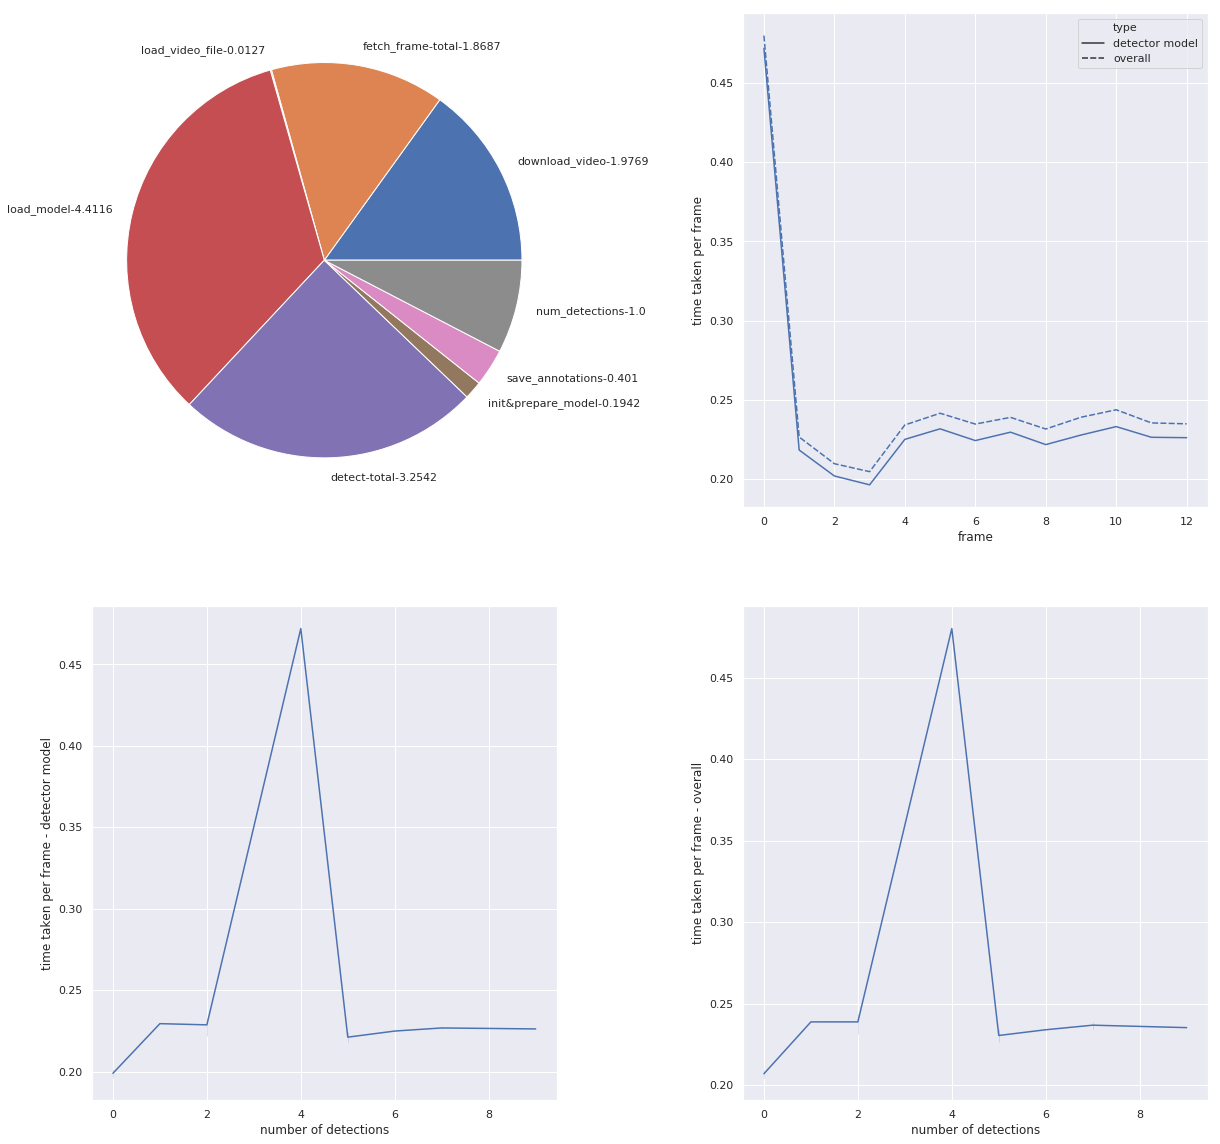

In [96]:
plot_data_for_file(data_ex,ints_ex,ints_dm,file_index = 0)

# Other metrics

In [97]:
print('Index ','\t Filename')
for i in range(len(data_ex)):
    print(data_ex.loc[str(i),'index'],'\t',data_ex.loc[str(i),'input_file'])

Index  	 Filename
0 	 Smart & intelligent Defenders 2019  🧠 Art Of Defence 💡.mp4
1 	 Smart & intelligent Defenders 2019  🧠 Art Of Defence 💡.mp4
2 	 Best Goals Of 2018.mp4
3 	 Best Goals Of 2018.mp4


Text(0.5, 1.0, 'Detection time inside detector model vs video duration')

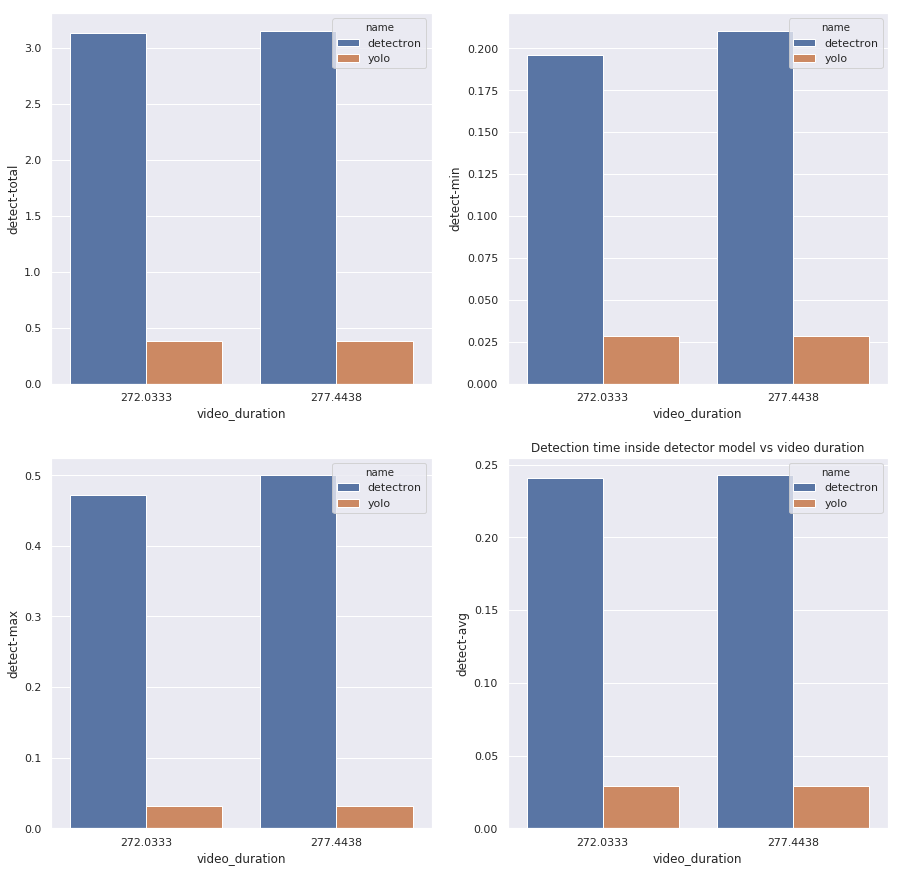

In [98]:
fig, axes = plt.subplots(2,2,figsize=(15,15))
xmetric = ['video_duration','index'][0]
dft = data_dm
sns.barplot(data=dft,x=xmetric,y='detect-total',ax=axes[0,0],hue='name')
sns.barplot(data=dft,x=xmetric,y='detect-min',ax=axes[0,1],hue='name')
sns.barplot(data=dft,x=xmetric,y='detect-max',ax=axes[1,0],hue='name')
sns.barplot(data=dft,x=xmetric,y='detect-avg',ax=axes[1,1],hue='name')

plt.title('Detection time inside detector model vs video duration')
#plt.legend(title='Video file name', loc='lower right', labels=data_ex.loc[:,'input_file'])

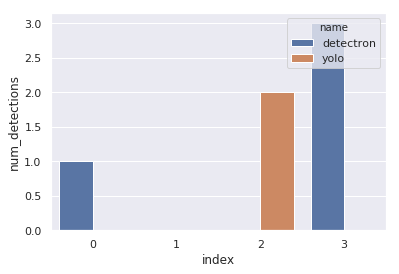

In [99]:
sns.barplot(data=data_ex,x='index',y='num_detections',hue='name')

In [100]:
# from fpdf import FPDF
 
# pdf = FPDF()
# pdf.add_page()
# pdf.set_font("Arial", size=12)
# pdf = FPDF(orientation='P', unit='mm', format='A4')
# pdf.cell(200, 10, txt="Welcome to Python!", ln=1, align="C")
# pdf.output("simple_demo.pdf")

# Report

## Pipeline

Index(['download_video', 'fetch_frame-total', 'load_video_file', 'load_model',
       'detect-total', 'init&prepare_model', 'save_annotations', 'index',
       'num_detections'],
      dtype='object')


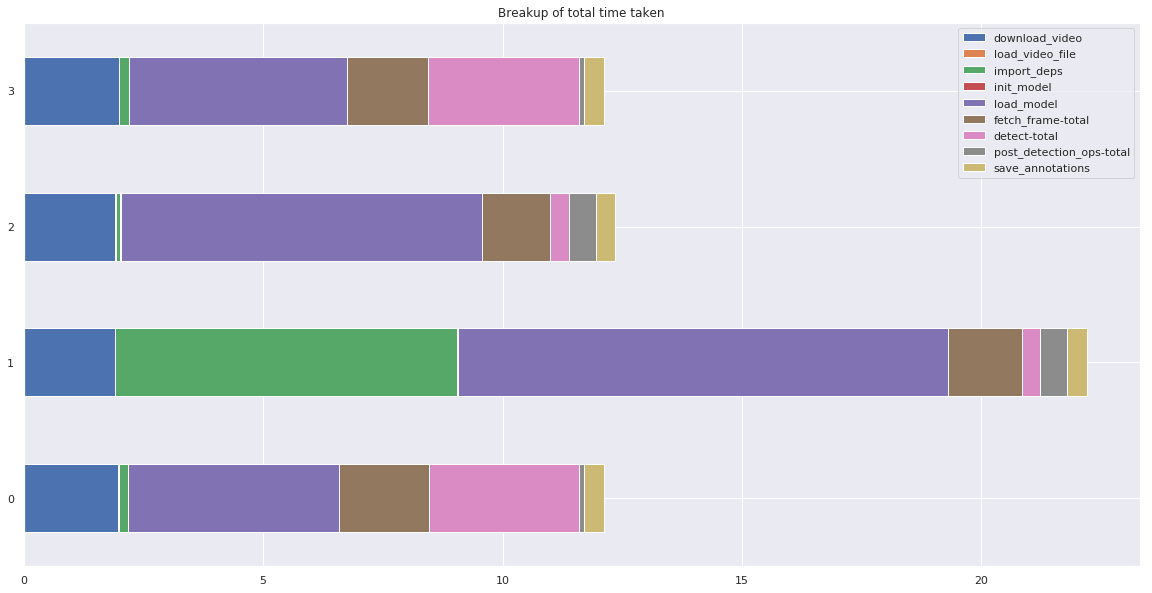

In [101]:
fig1,ax1 = plt.subplots()
dd = data_ex.drop( ['name','input_file','Total_time','video_duration','video_file_size'],axis=1)
dd=drop_cols(dd,['avg','min','max'])
print(dd.columns)
dd = dd[['download_video','load_video_file','fetch_frame-total', 'save_annotations']]#'init&prepare_model','load_model'
dd[['import_deps','init_model','load_model','detect-total','post_detection_ops-total']] = data_dm[['import_deps','init_model','load_model','detect-total','post_detection_ops-total']]


dd = dd[['download_video','load_video_file','import_deps','init_model','load_model','fetch_frame-total','detect-total','post_detection_ops-total','save_annotations']]
dd.plot(kind='barh', stacked=True,figsize=(20,2.5*len(dd)),title='Breakup of total time taken',ax=ax1)

' '

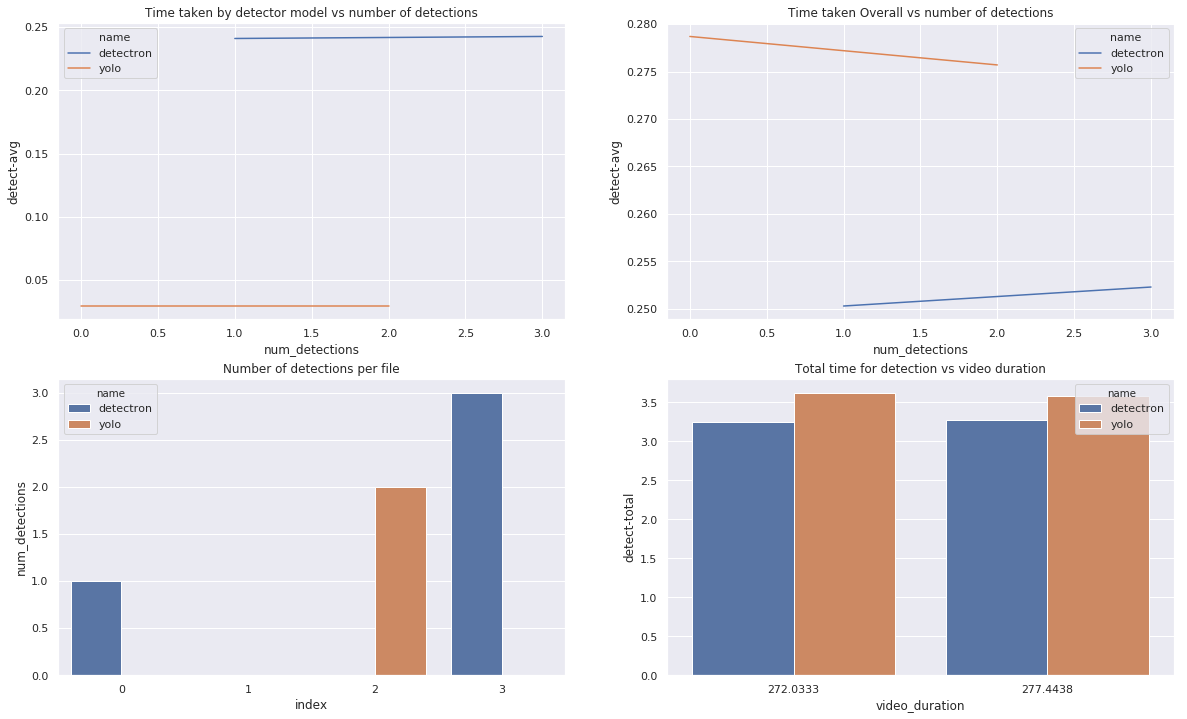

In [102]:
fig2,axs = plt.subplots(2,2,figsize=(20,12))
x,y,hue='num_detections','detect-avg','name'
sns.lineplot(data=data_dm,x=x,y=y,hue=hue,ax=axs[0,0]).set_title('Time taken by detector model vs number of detections')
sns.lineplot(data=data_ex,x=x,y=y,hue=hue,ax=axs[0,1]).set_title('Time taken Overall vs number of detections')
sns.barplot(data=data_dm,x='index',y='num_detections',hue='name',ax=axs[1,0]).set_title('Number of detections per file')
sns.barplot(data=data_ex,y='detect-total',hue='name',x='video_duration',ax=axs[1,1]).set_title('Total time for detection vs video duration')
' '

In [103]:
save_figs_as_pdf([fig1,fig2],'Report.pdf')